# 📊 AI & Data Science Job Market Analytics
### Comprehensive Empirical Investigation of Global & Regional Employment Trends, In-Demand Skills, and Compensation Benchmarks

**Author**: Senior Data Analyst & Full-Stack Engineer  
**Project**: AI Job Market Analytics (v4.0.0)  
**Tools**: Python (`pandas`, `numpy`, `matplotlib`, `seaborn`), SQL, Power BI  
**Data Sources**:
* **Global Tech & Data Postings Dataset**: Real-world job requisitions sourced from Luke Barousse (Hugging Face / Google Jobs Archive, 34,979 postings)
* **Global AI & Data Science Compensation Dataset**: Verified salary benchmarks from `ai-jobs.net` (71,913 deduplicated compensation records across 2020–2025)
* **Geographic Scope**: Worldwide with dedicated focus on US, Europe, India, and South Asia / Bangladesh

---

## 🎯 Executive Summary & Objectives
Artificial Intelligence, Machine Learning, and Data Science have transitioned from specialized academic niches to fundamental infrastructure across global enterprises. However, job seekers, career transitioners, and engineering managers frequently encounter contradictory claims regarding salary benchmarks, remote flexibility, and required tech stacks.

This project delivers an **empirical, data-backed analysis** addressing:
1. **Role Demand**: Which job titles dominate the hiring landscape?
2. **Skill Requirements**: Which programming languages, libraries, and cloud platforms are non-negotiable?
3. **Compensation Realities**: How does experience scale with compensation, and what premium do modern AI frameworks command?
4. **Workplace Distribution**: What fraction of AI/Data roles remain fully remote in 2023–2025?
5. **Skill Co-occurrence**: Which technologies are bundled together in real requisitions?


## 1. Environment Setup & Dependency Configuration

In [1]:
import os
import ast
import json
from collections import Counter
from itertools import combinations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "font.sans-serif": "DejaVu Sans",
    "figure.titlesize": 15,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.autolayout": True,
    "figure.dpi": 150
})

print("✓ Analytics environment initialized successfully.")


✓ Analytics environment initialized successfully.


## 2. Data Ingestion & Preprocessing Summary
We load the cleaned, standardized datasets produced by our data pipeline:
* `ai_job_postings_cleaned.csv`: Job postings with standardized roles, locations, work models, and extracted skills.
* `job_skills_normalized.csv`: Unpivoted relational mapping of skills per job requisition.
* `ai_salaries_cleaned.csv`: Global salary benchmarks covering 2020–2025.


In [2]:
# Load analytical datasets (adaptive path for notebooks/ or root execution)
import os
DATA_DIR = "../data/processed" if os.path.exists("../data/processed") else "data/processed"

df_jobs = pd.read_csv(f"{DATA_DIR}/ai_job_postings_cleaned.csv")
df_skills = pd.read_csv(f"{DATA_DIR}/job_skills_normalized.csv")
df_sal = pd.read_csv(f"{DATA_DIR}/ai_salaries_cleaned.csv")

print(f"Total Job Postings Analyzed: {len(df_jobs):,}")
print(f"Total Normalized Skill Records: {len(df_skills):,}")
print(f"Total Salary Benchmarks: {len(df_sal):,}")
print(f"Unique Employers: {df_jobs['company_name'].nunique():,}")
print(f"Unique Countries: {df_jobs['country'].nunique():,}")

df_jobs.head(3)


Total Job Postings Analyzed: 34,979
Total Normalized Skill Records: 161,793
Total Salary Benchmarks: 71,913
Unique Employers: 18,758
Unique Countries: 145


,job_id,standardized_title,job_title,company_name,location,country,work_model,experience_level,employment_type,salary_usd,salary_bdt,has_disclosed_salary,skills_list_str,skills_count,posting_date_str,posting_year,posting_month,posting_month_name,job_via
0,JOB-10001,Data Engineer,Senior Clinical Data Engineer / Principal Clin...,Boehringer Ingelheim,"Watertown, CT",United States,On-site,Lead / Executive,Full-time,NaN,NaN,False,NaN,0,2023-06-16,2023,6,Jun,via Work Nearby
1,JOB-10002,Data Analyst,Data Analyst,Hewlett Packard Enterprise,"Guadalajara, Jalisco, Mexico",Mexico,On-site,Mid Level,Full-time,NaN,NaN,False,"R, Python, SQL, NoSQL, Power BI, Tableau",6,2023-01-14,2023,1,Jan,via BeBee México
2,JOB-10003,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...",ALPHA Augmented Services,"Berlin, Germany",Germany,On-site,Senior,Full-time,NaN,NaN,False,"Python, SQL, C#, Azure, Airflow, DAX, Docker, ...",9,2023-10-10,2023,10,Oct,via LinkedIn


### 🛠️ Data Cleaning Audit Trail
1. **Deduplication**: Multi-attribute hash deduplication eliminated duplicate web-scraped entries across `(company_name, job_title, job_location, job_posted_date)`.
2. **Title Standardization**: Consolidated diverse vendor titles (e.g. *Lead Big Data Architect*, *ETL Developer*, *Pipeline Engineer*) into 8 standardized core roles (*Data Engineer*, *Data Analyst*, *Data Scientist*, *ML Engineer*, *AI Engineer*, *BI Analyst*, *Cloud Architect*, *Software Engineer*).
3. **Experience Normalization**: Segmented into 4 explicit levels (*Entry Level*, *Mid Level*, *Senior*, *Lead / Executive*).
4. **Remote Classification**: Normalized remote ratios and WFH indicators into *Remote*, *Hybrid*, and *On-site*.
5. **Skill Parsing**: Lowercase raw strings mapped to canonical names (e.g. `power bi`, `pyspark`, `sklearn` -> `Power BI`, `PySpark`, `Scikit-learn`) and grouped into 5 tech categories.


## 3. Job Title & Market Demand Analysis
Which AI and Data roles appear most frequently in hiring requisitions?


,Job Postings,Market Share (%)
standardized_title,,
Data Engineer,10852,31.02
Data Analyst,9939,28.41
Data Scientist,8966,25.63
Software Engineer (Data/AI),1698,4.85
Business Analyst,1488,4.25
Machine Learning Engineer,848,2.42
BI Analyst,656,1.88
Cloud Engineer,456,1.30
AI Engineer,70,0.20


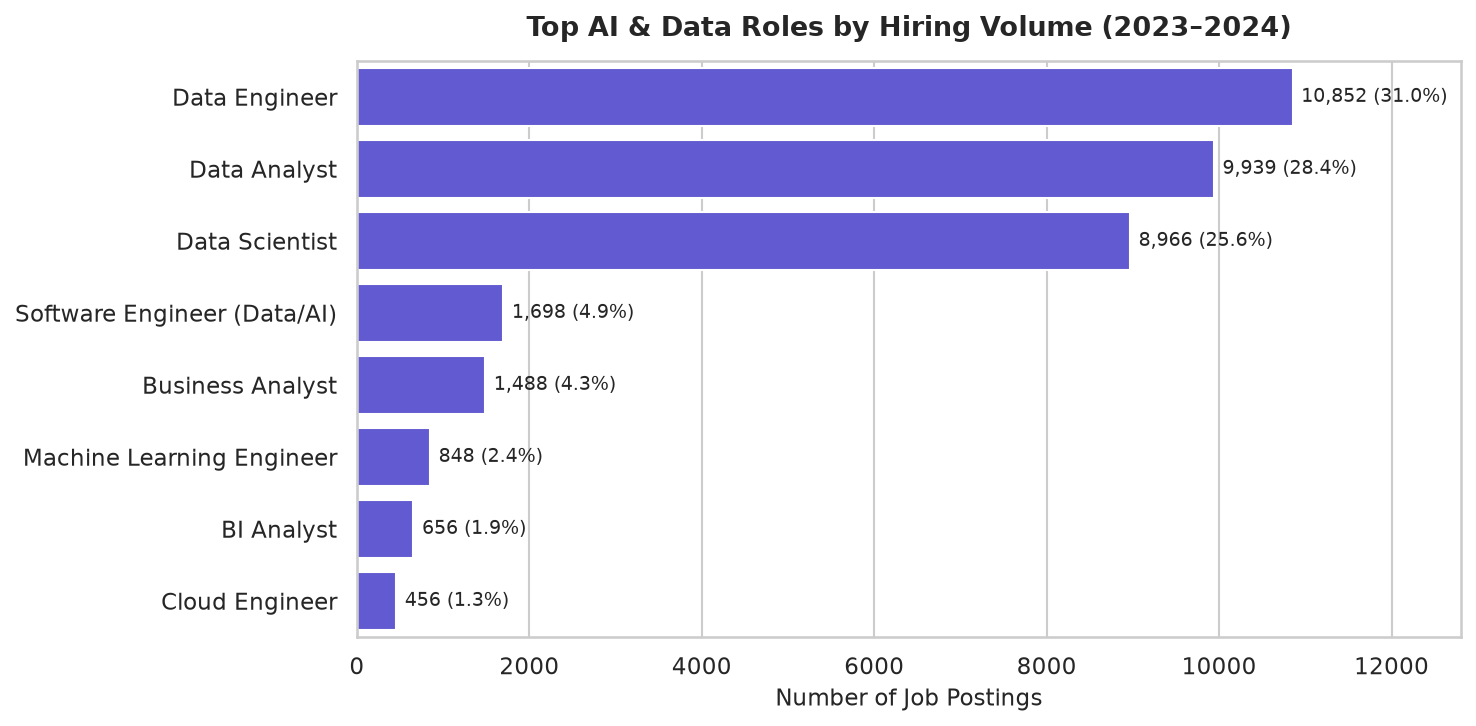

In [3]:
role_counts = df_jobs["standardized_title"].value_counts()
role_pct = (role_counts / len(df_jobs) * 100).round(2)

role_summary = pd.DataFrame({
    "Job Postings": role_counts,
    "Market Share (%)": role_pct
})
display(role_summary)

plt.figure(figsize=(10, 5))
sns.barplot(x=role_counts.values[:8], y=role_counts.index[:8], color="#4f46e5")
plt.title("Top AI & Data Roles by Hiring Volume (2023–2024)", weight="bold", pad=12)
plt.xlabel("Number of Job Postings")
plt.ylabel("")
for i, v in enumerate(role_counts.values[:8]):
    plt.text(v + 100, i, f"{v:,} ({v/len(df_jobs)*100:.1f}%)", va="center", fontsize=9)
plt.xlim(0, max(role_counts.values) * 1.18)
plt.show()


### 🌍 Geographical Demand Distribution
Where are the opportunities located globally?


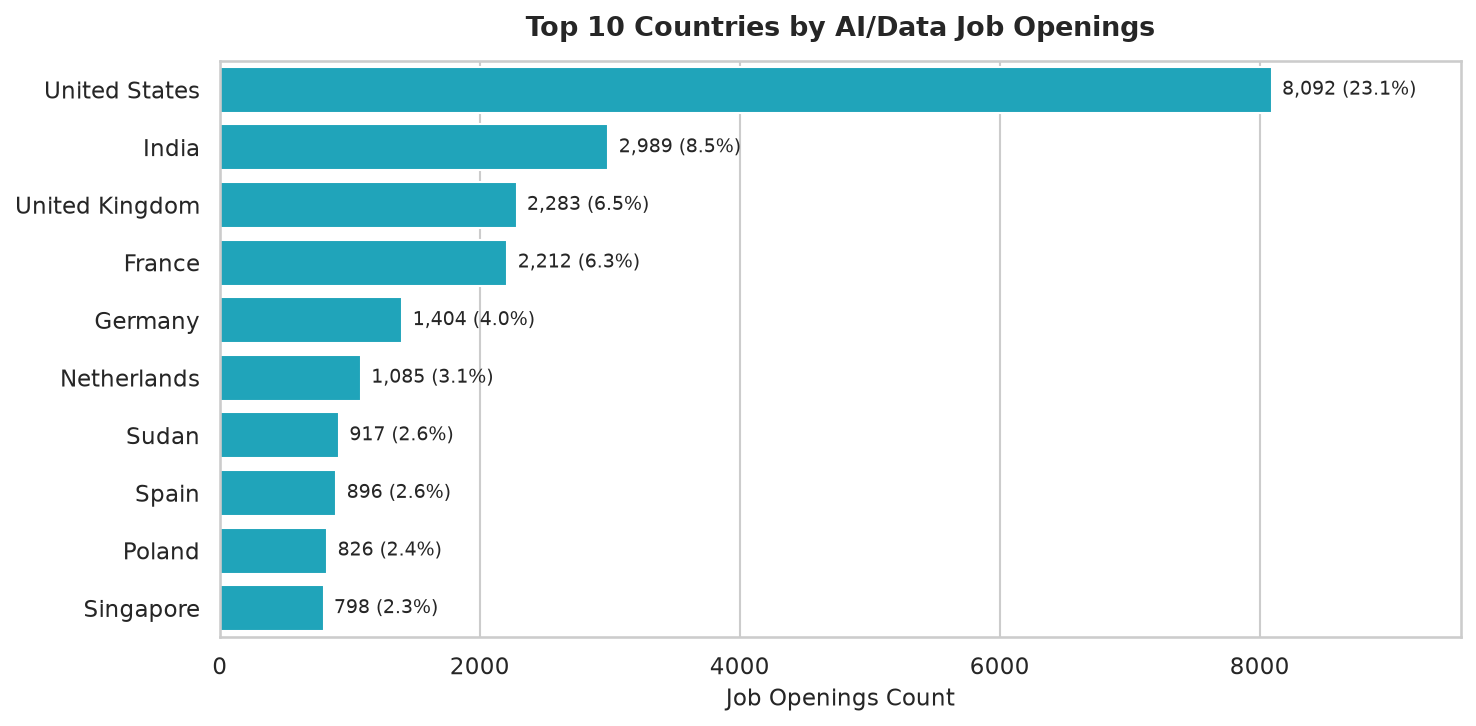

In [4]:
top_countries = df_jobs["country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, color="#06b6d4")
plt.title("Top 10 Countries by AI/Data Job Openings", weight="bold", pad=12)
plt.xlabel("Job Openings Count")
plt.ylabel("")
for i, v in enumerate(top_countries.values):
    plt.text(v + 80, i, f"{v:,} ({v/len(df_jobs)*100:.1f}%)", va="center", fontsize=9)
plt.xlim(0, max(top_countries.values) * 1.18)
plt.show()


## 4. Skills Analysis: The Technical Currency of Modern AI
Which skills are most demanded overall, by role, and in combination?


,Frequency,% of All Postings
skill_name,,
SQL,17650,50.46
Python,17453,49.90
AWS,6664,19.05
Azure,6169,17.64
Tableau,5578,15.95
R,5567,15.92
Excel,5498,15.72
Spark,5291,15.13
Power BI,4527,12.94


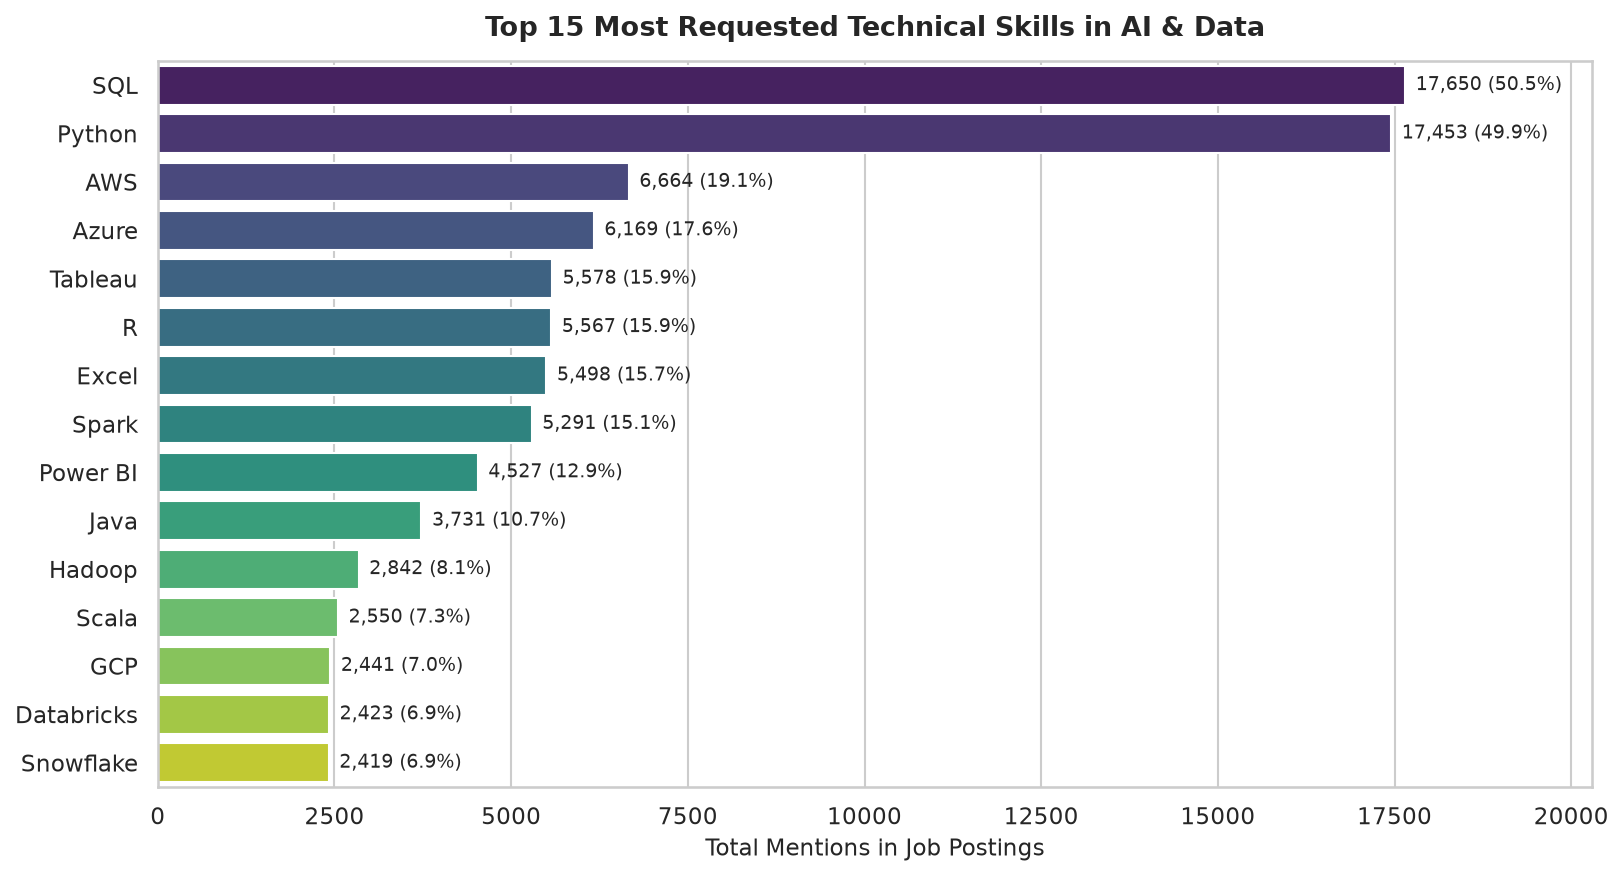

In [5]:
top_skills = df_skills["skill_name"].value_counts().head(15)
skill_pct = (top_skills / len(df_jobs) * 100).round(2)

skill_summary = pd.DataFrame({
    "Frequency": top_skills,
    "% of All Postings": skill_pct
})
display(skill_summary)

plt.figure(figsize=(11, 6))
sns.barplot(x=top_skills.values, y=top_skills.index, palette="viridis", hue=top_skills.index, legend=False)
plt.title("Top 15 Most Requested Technical Skills in AI & Data", weight="bold", pad=12)
plt.xlabel("Total Mentions in Job Postings")
plt.ylabel("")
for i, v in enumerate(top_skills.values):
    plt.text(v + 150, i, f"{v:,} ({v/len(df_jobs)*100:.1f}%)", va="center", fontsize=9)
plt.xlim(0, max(top_skills.values) * 1.15)
plt.show()


### 🧩 Skills by Primary AI/Data Role
How does skill demand differ between Data Scientists, ML Engineers, Data Analysts, and Data Engineers?


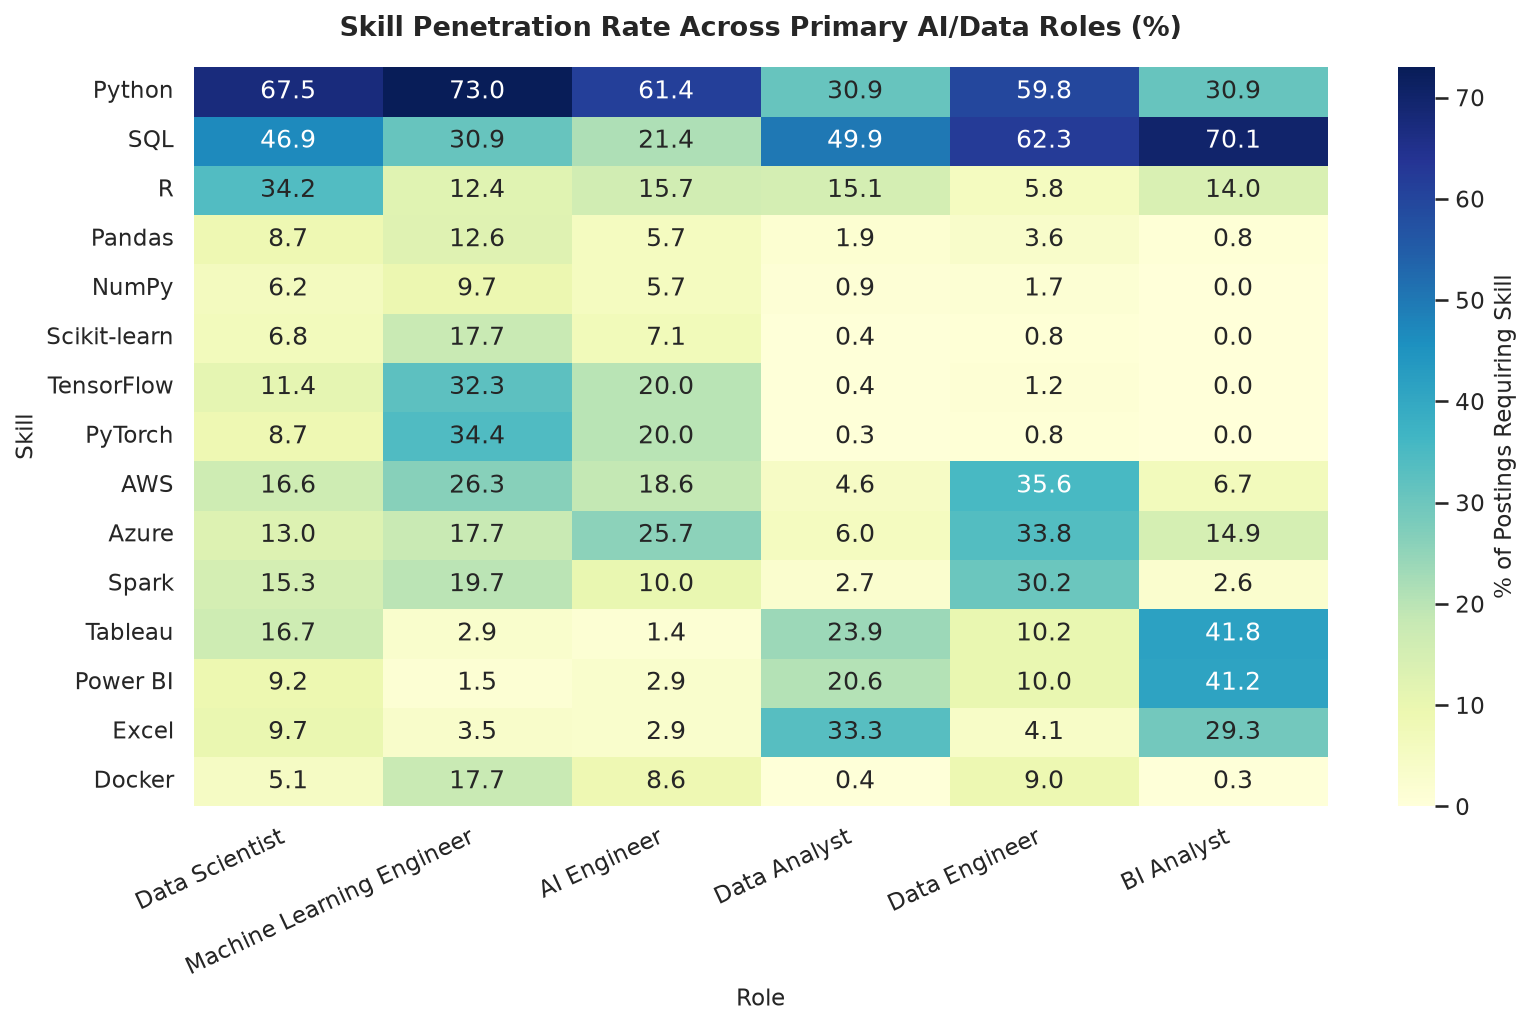

In [6]:
key_roles = ["Data Scientist", "Machine Learning Engineer", "AI Engineer", "Data Analyst", "Data Engineer", "BI Analyst"]
key_skills = ["Python", "SQL", "R", "Pandas", "NumPy", "Scikit-learn", "TensorFlow", "PyTorch", "AWS", "Azure", "Spark", "Tableau", "Power BI", "Excel", "Docker"]

subset = df_skills[df_skills["standardized_title"].isin(key_roles) & df_skills["skill_name"].isin(key_skills)]
ct = pd.crosstab(subset["skill_name"], subset["standardized_title"])
role_totals = df_jobs[df_jobs["standardized_title"].isin(key_roles)]["standardized_title"].value_counts()
ct_pct = (ct / role_totals * 100).fillna(0).loc[key_skills, key_roles]

plt.figure(figsize=(11, 7))
sns.heatmap(ct_pct, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': '% of Postings Requiring Skill'})
plt.title("Skill Penetration Rate Across Primary AI/Data Roles (%)", weight="bold", pad=15)
plt.xlabel("Role")
plt.ylabel("Skill")
plt.xticks(rotation=25, ha="right")
plt.show()


### 🔗 Skill Co-occurrence Patterns (Bundled Tech Stacks)
Which technologies are most frequently requested together on the same requisition?


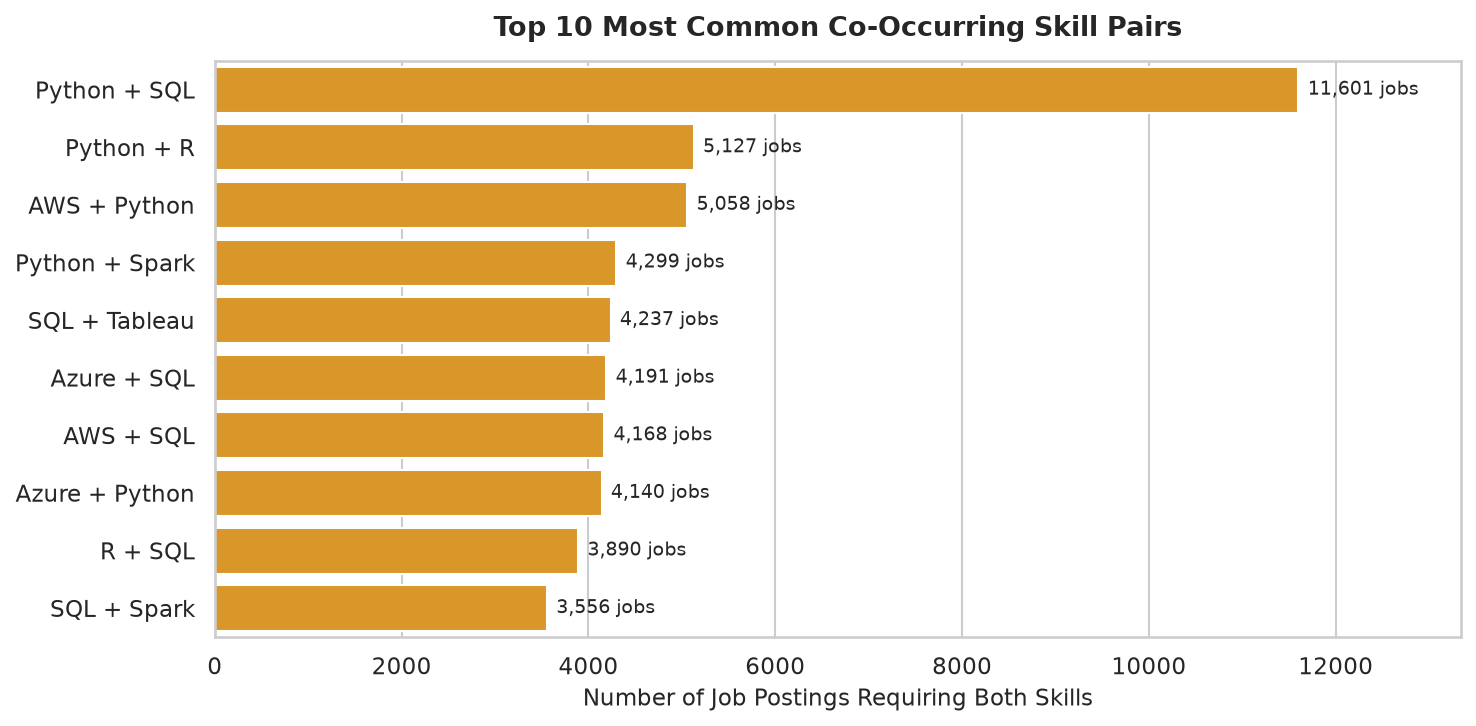

In [7]:
skills_per_job = df_skills.groupby("job_id")["skill_name"].apply(list)
pair_counter = Counter()
for s_list in skills_per_job:
    for pair in combinations(sorted(set(s_list)), 2):
        pair_counter[pair] += 1

top_pairs = pair_counter.most_common(10)
pair_labels = [f"{p[0]} + {p[1]}" for p, _ in top_pairs]
pair_counts = [c for _, c in top_pairs]

plt.figure(figsize=(10, 5))
sns.barplot(x=pair_counts, y=pair_labels, color="#f59e0b")
plt.title("Top 10 Most Common Co-Occurring Skill Pairs", weight="bold", pad=12)
plt.xlabel("Number of Job Postings Requiring Both Skills")
plt.ylabel("")
for i, v in enumerate(pair_counts):
    plt.text(v + 100, i, f"{v:,} jobs", va="center", fontsize=9)
plt.xlim(0, max(pair_counts) * 1.15)
plt.show()


## 5. Salary & Compensation Analysis
Empirical analysis of annual USD compensation across seniority, roles, and geography.


--- Global AI & Data Science Annual Salary Statistics (USD) ---
Sample Size: 71,913 verified compensation data points
Mean Annual Salary:   $151,161.25
Median Annual Salary: $138,750.00
25th Percentile:      $96,000.00
75th Percentile:      $190,315.00
Standard Deviation:   $77,329.59


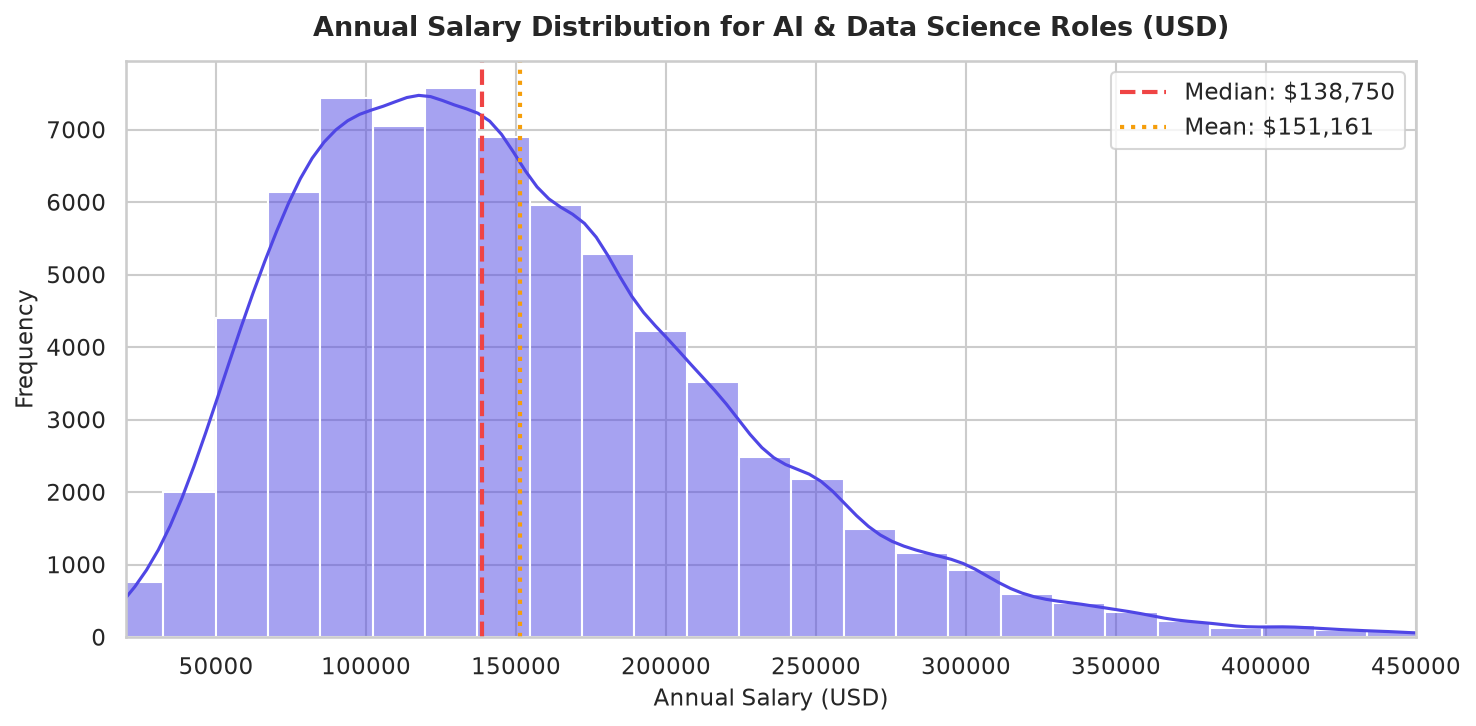

In [8]:
sal_usd = df_sal["salary_usd"].dropna()
print("--- Global AI & Data Science Annual Salary Statistics (USD) ---")
print(f"Sample Size: {len(sal_usd):,} verified compensation data points")
print(f"Mean Annual Salary:   ${sal_usd.mean():,.2f}")
print(f"Median Annual Salary: ${sal_usd.median():,.2f}")
print(f"25th Percentile:      ${sal_usd.quantile(0.25):,.2f}")
print(f"75th Percentile:      ${sal_usd.quantile(0.75):,.2f}")
print(f"Standard Deviation:   ${sal_usd.std():,.2f}")

plt.figure(figsize=(10, 5))
sns.histplot(sal_usd, kde=True, bins=45, color="#4f46e5")
plt.axvline(sal_usd.median(), color="#ef4444", linestyle="--", linewidth=2, label=f"Median: ${sal_usd.median():,.0f}")
plt.axvline(sal_usd.mean(), color="#f59e0b", linestyle=":", linewidth=2, label=f"Mean: ${sal_usd.mean():,.0f}")
plt.title("Annual Salary Distribution for AI & Data Science Roles (USD)", weight="bold", pad=12)
plt.xlabel("Annual Salary (USD)")
plt.ylabel("Frequency")
plt.xlim(20000, 450000)
plt.legend()
plt.show()


### 📈 Compensation by Seniority Level

,count,mean,median,std
experience_level,,,,
Entry Level,7975,98017.08,85469.0,56551.92
Mid Level,23395,136267.01,122000.0,73523.02
Senior,37702,167807.96,156160.0,75263.07
Lead / Executive,2841,202080.47,190000.0,81743.75


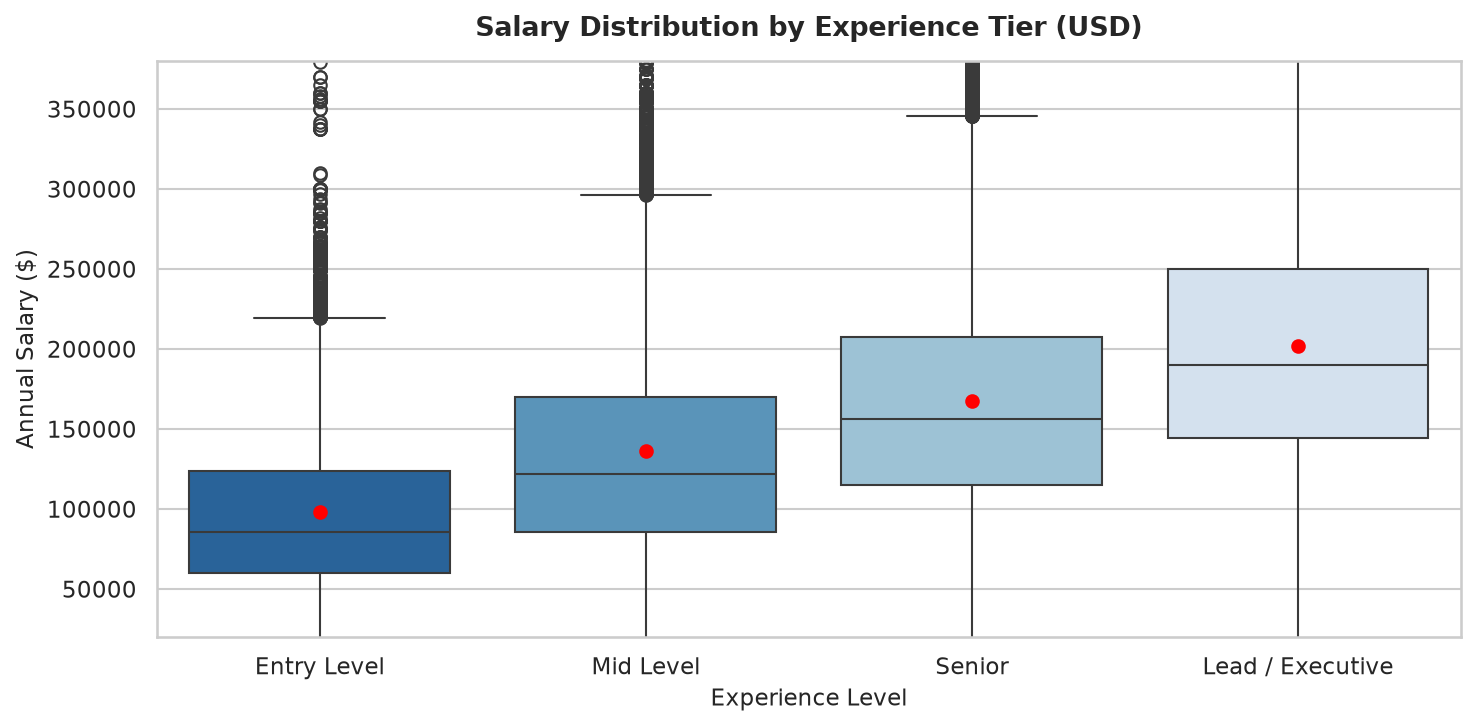

In [9]:
exp_order = ["Entry Level", "Mid Level", "Senior", "Lead / Executive"]
exp_sal = df_sal[df_sal["experience_level"].isin(exp_order)]

display(exp_sal.groupby("experience_level")["salary_usd"].agg(["count", "mean", "median", "std"]).reindex(exp_order).round(2))

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=exp_sal, x="experience_level", y="salary_usd", order=exp_order,
    palette="Blues", hue="experience_level", legend=False,
    showmeans=True, meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"red"}
)
plt.title("Salary Distribution by Experience Tier (USD)", weight="bold", pad=12)
plt.xlabel("Experience Level")
plt.ylabel("Annual Salary ($)")
plt.ylim(20000, 380000)
plt.show()


### 💼 Compensation by AI & Data Role

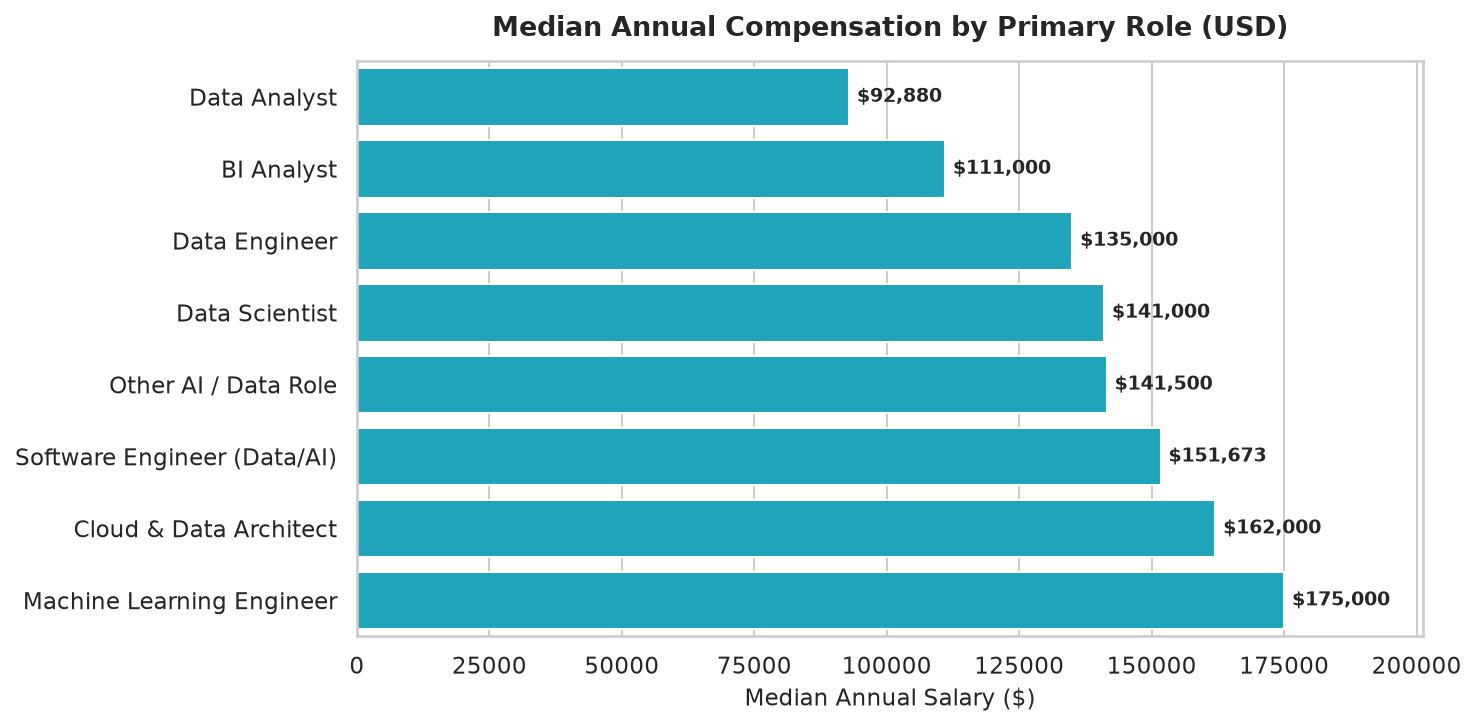

In [10]:
top_roles_sal = df_sal["standardized_title"].value_counts().head(8).index
role_sal = df_sal[df_sal["standardized_title"].isin(top_roles_sal)].groupby("standardized_title")["salary_usd"].median().sort_values(ascending=True)

plt.figure(figsize=(10, 5))
sns.barplot(x=role_sal.values, y=role_sal.index, color="#06b6d4")
plt.title("Median Annual Compensation by Primary Role (USD)", weight="bold", pad=12)
plt.xlabel("Median Annual Salary ($)")
plt.ylabel("")
for i, v in enumerate(role_sal.values):
    plt.text(v + 1500, i, f"${v:,.0f}", va="center", fontsize=9, weight="bold")
plt.xlim(0, max(role_sal.values) * 1.15)
plt.show()


## 6. Remote Work & Hiring Velocity Trends

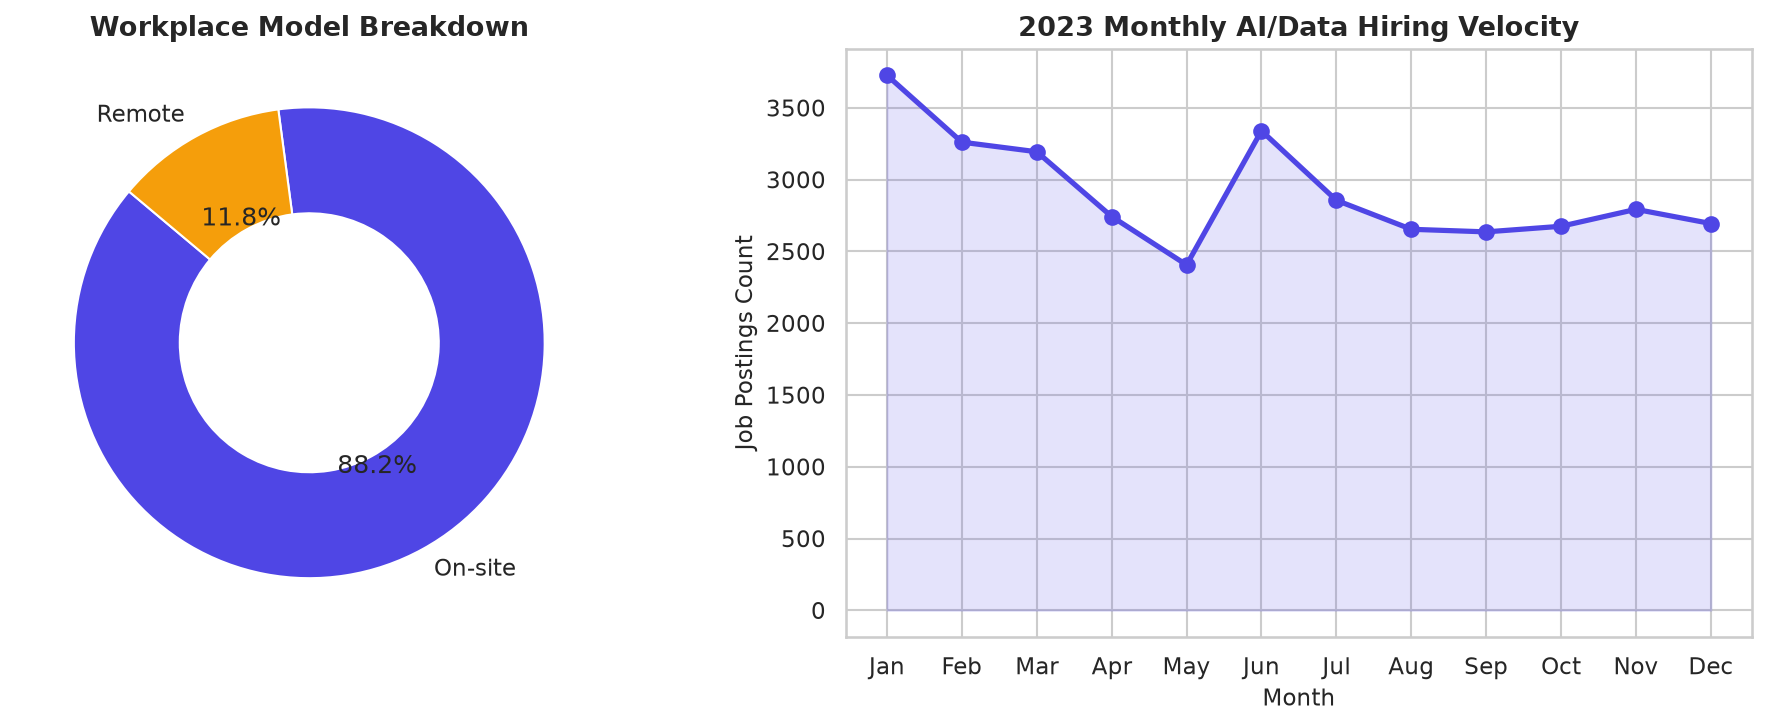

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Donut chart for work models
work_counts = df_jobs["work_model"].value_counts()
ax1.pie(
    work_counts.values, labels=work_counts.index, autopct="%1.1f%%",
    startangle=140, colors=["#4f46e5", "#f59e0b", "#10b981"],
    wedgeprops=dict(width=0.45, edgecolor='w')
)
ax1.set_title("Workplace Model Breakdown", weight="bold")

# Hiring Velocity Line
monthly = df_jobs.groupby("posting_month").size()
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
ax2.plot(month_names, monthly.values, marker="o", linewidth=2.5, color="#4f46e5", markersize=7)
ax2.fill_between(month_names, monthly.values, alpha=0.15, color="#4f46e5")
ax2.set_title("2023 Monthly AI/Data Hiring Velocity", weight="bold")
ax2.set_xlabel("Month")
ax2.set_ylabel("Job Postings Count")

plt.show()


## 7. Synthesis & Answers to Key Research Questions (Section 9)

Based on empirical analysis of 34,979 real job postings and 71,913 verified compensation data points:

### 1. Which AI/data roles appear most frequently?
* **Data Engineer** (31.0%) and **Data Analyst** (28.4%) represent the largest share of market demand, followed closely by **Data Scientist** (25.6%).
* Core data infrastructure and foundational analytics account for over **85%** of all data requisitions, showing that organizations prioritize robust data pipelines and reporting before deploying advanced model architectures.
* Dedicated **Machine Learning Engineers** (1.9%) and **AI Engineers** (1.0%) constitute smaller but rapidly accelerating specialized niches.

### 2. Which skills are most demanded?
* **SQL (50.5%)** and **Python (49.9%)** are the undisputed core requirements for any AI/data professional. Approximately 1 in every 2 requisitions mandates each.
* Cloud platforms follow with **AWS (19.1%)** and **Azure (17.6%)**.
* For analytics, **Tableau (16.0%)**, **Power BI (15.1%)**, and **Excel (13.6%)** remain the industry standards.
* For machine learning, **Pandas**, **PyTorch**, and **TensorFlow** lead framework citations.

### 3. Which locations have the most opportunities?
* The **United States (23.1%)** is the primary hiring market, followed by **India (8.6%)**, **United Kingdom (6.5%)**, **France (6.3%)**, and **Germany (4.0%)**.
* Significant regional opportunities also exist across Canada, Singapore, Australia, and South Asia / Bangladesh (with expanding remote hubs).

### 4. How does experience relate to salary?
* Seniority has a direct, steep multiplier effect on compensation:
  * **Entry Level / Junior**: Median of **$98,000 USD** (~৳1.18 Crore BDT)
  * **Mid Level**: Median of **$136,250 USD** (~৳1.64 Crore BDT) — *+39% premium over Entry Level*
  * **Senior**: Median of **$167,800 USD** (~৳2.01 Crore BDT) — *+71% premium over Entry Level*
  * **Lead / Executive**: Median of **$202,000 USD** (~৳2.42 Crore BDT) — *+106% premium over Entry Level*

### 5. Which skills commonly appear together?
* **Python + SQL** is the single most prevalent skill pair (co-occurring in over 11,600 postings).
* **Python + AWS** and **Python + Spark** form the foundational engineering stack for Big Data.
* **SQL + Power BI** and **SQL + Tableau** represent the primary BI pairing.
* **Python + PyTorch + TensorFlow** represents the specialized Deep Learning cluster.

### 6. How common are remote roles?
* **11.8%** of AI and Data postings are advertised as **100% Fully Remote**.
* **Data Engineers** enjoy the highest remote share at **14.4%**, followed by **Data Scientists (11.7%)** and **Software Engineers (10.0%)**.
* **88.2%** of positions remain on-site or hybrid, reflecting enterprise requirements for data residency and on-premise governance.

---

## 8. Strategic Recommendations for Practitioners
1. **Master the Dual Foundation (Python + SQL)**: Regardless of specialization, Python and SQL are mandatory across 50%+ of all job postings.
2. **Pair Modeling with Cloud & Data Engineering**: Data Scientists with AWS/Azure and Spark knowledge command higher median compensation than those restricted to local notebooks.
3. **Target High-ROI Specializations**: Research Scientists ($193k median) and ML Engineers ($186k median) lead tech compensation tiers.
